# Centrality Foundations
### Graph Theory and Network Centralities
 
This notebook implements and analyzes various network centralities and the friendship paradox phenomenon.

## I. Importations

In [1]:
import numpy as np
import torch
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import expm_multiply
from scipy.sparse.linalg import eigs
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx
from scipy.linalg import expm
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## II. Dataset

In [2]:
graphs = {}

# 1.Karate Club
graphs["Karate Club"] = nx.karate_club_graph()

# 2.Florentine Families (Dolphins)
graphs["Dolphins"] = nx.generators.social.florentine_families_graph()

# 3.Les Miserables
graphs["Les Miserables"] = nx.generators.social.les_miserables_graph()

# 4.Cora
dataset_cora = Planetoid(root="./data", name="Cora")
cora = to_networkx(dataset_cora[0], to_undirected=True)
graphs["Cora"] = cora

# 5.CiteSeer
dataset_citeseer = Planetoid(root="./data", name="CiteSeer")
citeseer = to_networkx(dataset_citeseer[0], to_undirected=True)
graphs["CiteSeer"] = citeseer

In [3]:
table_data = []

for name, g in graphs.items():
    g_simple = nx.Graph(g)
    
    n = g_simple.number_of_nodes()
    m = g_simple.number_of_edges()
    avg_degree = (2 * m) / n if n > 0 else 0
    density = nx.density(g_simple)
    
    table_data.append({
        "Dataset": name,
        "Nodes": n,
        "Edges": m,
        "Avg. Degree": f"{avg_degree:.2f}",
        "Density": f"{density:.4f}"
    })

df = pd.DataFrame(table_data)
print(df.to_string(index=False))

       Dataset  Nodes  Edges Avg. Degree Density
   Karate Club     34     78        4.59  0.1390
      Dolphins     15     20        2.67  0.1905
Les Miserables     77    254        6.60  0.0868
          Cora   2708   5278        3.90  0.0014
      CiteSeer   3327   4552        2.74  0.0008


## III. Centrality Definitions

Given a graph with adjacency matrix $A$, degree vector $\mathbf{d} = A\mathbf{1}$, and diagonal degree matrix $D = \operatorname{diag}(\mathbf{d})$:

- **Degree Centrality**: $\mathbf{d} = A\mathbf{1}$
- **Eigenvector Centrality**: $A\mathbf{x} = \lambda\mathbf{x}$ (leading eigenvector)
- **Walk Centrality**: $\mathbf{x} = A^\ell\mathbf{1}$
- **Katz Centrality**: $(I - \alpha A)\mathbf{x} = \mathbf{1}$
- **Exponential Centrality**: $\mathbf{x} = \exp(\alpha A)\mathbf{1}$
- **Nonbacktracking Centrality**: First $n$ entries of the leading eigenvector of

$$
B =
\begin{bmatrix}
A & I-D \\
I & 0
\end{bmatrix}
$$

#### 1. Degree Centrality

In [4]:
def degree_centrality(G, node) : 
    return G.degree[node]

#### 2. Eigenvector Centrality

In [5]:
def eigenvector_centrality(G, node, max_iter=1000) :
    c = nx.eigenvector_centrality(
        G,
        max_iter=max_iter,
        tol=1e-8
    )
    return c[node]

#### 3. Walk Centrality

In [6]:
def walk_centrality(G, node, l=2) :
    A = nx.to_numpy_array(G)
    x = np.linalg.matrix_power(A,l) @ np.ones(len(G))
    nodes = list(G.nodes())
    
    return x[nodes.index(node)] 

#### 4. Katz Centrality

In [7]:
def katz_centrality(G, node, alpha=None):
    try:
        A = nx.to_numpy_array(G)
        eigvals = np.linalg.eigvalsh(A)
        lambda_max = max(abs(eigvals)) if len(eigvals) > 0 else 0
        
        if alpha is None:
            alpha = 0.8 / lambda_max if lambda_max > 0 else 0.1
        else:
            if lambda_max > 0 and alpha >= 1/lambda_max:
                alpha = 0.8 / lambda_max
        
        c = nx.katz_centrality(
            G, 
            alpha=alpha, 
            beta=1.0, 
            max_iter=5000, 
            tol=1e-6,
            nstart={n: 1 for n in G.nodes()} 
        )
        return c[node]
    except nx.PowerIterationFailedConvergence:
        try:
            if lambda_max > 0:
                alpha = 0.5 / lambda_max
            else:
                alpha = 0.05
            c = nx.katz_centrality(
                G, 
                alpha=alpha, 
                beta=1.0, 
                max_iter=5000, 
                tol=1e-6,
                nstart={n: 1 for n in G.nodes()}
            )
            return c[node]
        except:
            return np.nan
    except Exception:
        return np.nan

#### 5. Exponential Centrality

In [8]:
def exponential_centrality(G, node, alpha=0.1):
    nodes = list(G.nodes())
    node_to_idx = {n: i for i, n in enumerate(nodes)}

    # Sparse adjacency matrix
    A = nx.to_scipy_sparse_array(
        G,
        nodelist=nodes,
        format='csr',
        dtype=float
    )

    # Compute exp(alpha A) @ 1 directly
    ones = np.ones(len(nodes))
    x = expm_multiply(alpha * A, ones)

    return float(x[node_to_idx[node]])

#### 6. Nonbacktracking Centrality

In [9]:
def nonbacktracking_centrality(G, node, max_iter=100, tol=1e-5):
    n = len(G)
    if n == 0:
        return np.nan

    nodes = list(G.nodes())
    if node not in G:
        return np.nan

    idx = nodes.index(node)

    try:
        A_np = nx.to_numpy_array(G, nodelist=nodes)
        degrees = np.array([G.degree(v) for v in nodes])

        I_np = np.eye(n)
        D_np = np.diag(degrees)
        B_np = np.block([[A_np, I_np - D_np], [I_np, np.zeros((n, n))]])

        B = torch.tensor(B_np, dtype=torch.float32, device=device)

        v = torch.ones((2 * n, 1), dtype=torch.float32, device=device)
        v = v / torch.norm(v)

        for _ in range(max_iter):
            v_next = torch.matmul(B, v)
            norm = torch.norm(v_next)
            if norm == 0:
                break
            v_next = v_next / norm
            if torch.norm(v_next - v) < tol:
                v = v_next
                break
            v = v_next

        x = v[:n].squeeze()
        x_norm = torch.norm(x)
        if x_norm > 0:
            x = x / x_norm

        return float(x[idx].item())

    except Exception:
        return np.nan

In [10]:
def all_centralities(G, node):
    return {
        "degree": degree_centrality(G, node),
        "eigenvector": eigenvector_centrality(G, node),
        "walk": walk_centrality(G, node),
        "katz": katz_centrality(G, node),
        "exponential": exponential_centrality(G, node),
        "nonbacktracking": nonbacktracking_centrality(G, node)
    }

#### Plot Centralities and Node Neighborhood

In [11]:
def plot_node_neighborhood_and_centralities(G, node):

    neighbors = list(G.neighbors(node))
    sub_nodes = [node] + neighbors
    H = G.subgraph(sub_nodes)

    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(H, seed=42)

    nx.draw_networkx_edges(H, pos, alpha=0.5)

    nx.draw_networkx_nodes(
        H,
        pos,
        nodelist=[node],
        node_color="red",
        node_size=500,
        label="Node of Interest"
    )

    nx.draw_networkx_nodes(
        H,
        pos,
        nodelist=neighbors,
        node_color="skyblue",
        node_size=300,
        label="Neighbors"
    )

    nx.draw_networkx_labels(H, pos)

    plt.title(f"Neighborhood of node {node}")
    plt.legend()
    plt.axis("off")
    
    filename = f"figs/neighborhood_node_{node}.pdf"
    plt.savefig(
        filename,
        bbox_inches="tight"
    )
    plt.show()

    print(all_centralities(G=graphs["Karate Club"], node=0))

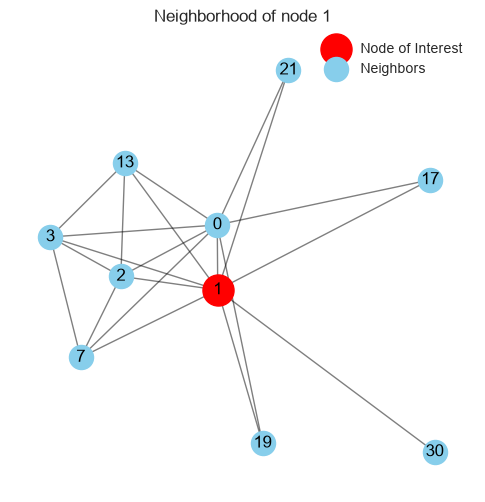

{'degree': 16, 'eigenvector': 0.355491364096938, 'walk': np.float64(646.0), 'katz': np.float64(0.23756052819039533), 'exponential': 13.243910310437672, 'nonbacktracking': 0.3090530335903168}


In [12]:
plot_node_neighborhood_and_centralities(G=graphs["Karate Club"], node=1)